In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv(r'C:\Users\Edunet Foundation\Desktop\Students_handover\Standardization\Social_Network_Ads (1).csv')

In [42]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [43]:
df.iloc[:,2:4]

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [44]:
df=df.iloc[:,2:]

In [45]:
df.sample(10)

,Age,EstimatedSalary,Purchased
351,37,75000,0
249,35,97000,1
233,49,86000,1
76,18,52000,0
347,54,108000,1
218,46,96000,0
283,52,21000,1
81,39,42000,0
328,36,118000,1
384,57,33000,1


In [46]:
x = df[['Age','EstimatedSalary']]
y = df['Purchased']



# 1️ Why do we **split the data**?


> **Model ko exam dene se pehle question paper nahi dikhana chahiye.**

---

##  Real-life example

Socho tum student ho:

*  **Practice notebook** → training data
*  **Final exam paper** → test data

Agar teacher exam ka paper pehle dikha de:

* marks achhe aayenge
* lekin **real learning nahi hui**

ML me bhi same cheez hoti hai.

---

##  ML language

```python
X_train, X_test, y_train, y_test = train_test_split(...)
```

* **X_train** → model yahin se seekhta hai
* **y_train** → correct answers (labels)
* **X_test** → model ko test karne ke liye
* **y_test** → actual answers (checking)

 Isse pata chalta hai:

> “Model naye data pe kitna acha kaam karega?”

---

## Agar split nahi karoge to?

* Model data **yaad** kar lega (overfitting)
* Accuracy fake high lagegi
* Real world me fail 

---


### Always split the data

In [8]:
# Train test split we need to use always before scaling the data because we want to avoid data leakage
from sklearn.model_selection import train_test_split

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((320, 2), (80, 2), (320,), (80,))

In [ ]:
# Now in sckit-learn we have a class called StandardScaler which will help us to standardize the data which has same formula as mentioned above



In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
# Now standardscclar class ka object banate hain q ki bina object ke hum use nahi kar sakte hain qki class ke andar methods hote hain jise use karne ke liye hume object banana padta hai
scaler = StandardScaler()

In [51]:
# ab fit method se hum apne training data ke mean aur standard deviation ko calculate karenge
# fit krta ye hai ki wo hmaare training data ke mean aur standard deviation ko calculate krta hai
scaler.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True




### 1️ `copy = True`

**Original data safe rahega**

* True = data copy banegi 
* False = original data bigad sakta hai 

**Hamesha True rehne do**

---

### 2️ `with_mean = True`

**Average (mean) hata ke data ko center karna**

* True = proper scaling 
* False = half kaam 

 **Hamesha True**

---

### 3️ `with_std = True`

**Data ko same level pe lana**

* True = sahi scaling 
* False = data uneven 



In [53]:
scaler.mean_

array([3.7871875e+01, 7.0281250e+04])

In [ ]:
scaler.scale_

array([1.01915631e+01, 3.43767130e+04])

In [52]:
# ab transform method se hum apne training data ko standardize karenge
# transform() = jo fit() ne seekha, usko data pe apply karna

# train sirf hm X-train ko krte h but transform dono pe krte h qki hmaare model ko dono data pe standardize data chahiye hota hai
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


fit() kya tha?

class ke marks dekhe

average nikaala

grading rule banaya

transform() kya karta hai?

usi grading rule se

sab students ko grade deta hai

Rule naya nahi banta, bas apply hota hai.


# 2️ Why do we **standardize (scale) X_train & X_test**?


> **Sab features ko same level pe lana**

---

##  Problem without scaling

Tumhara data:

| Feature | Range             |
| ------- | ----------------- |
| Age     | 18 – 60           |
| Salary  | 20,000 – 1,20,000 |

Salary ki values bahut badi hain
Model bolega:

> “Salary hi sab kuch hai, Age ignore!”

⚠️ Ye unfair ho jata hai.

---

# 3️ Why **fit scaler on X_train only**?


```python
scaler.fit(X_train)
```

👉 Kyunki:

* X_train = real world ka example
* Model sirf yahin se seekhe

---

##  Galat approach

```python
scaler.fit(X_test)   
```

Matlab:

* exam paper dekh ke padhna
* cheating
* data leakage

---

# 4️ Why do we **transform X_test** then?

```python
scaler.transform(X_test)
```

👉 Kyunki:

* Test data bhi **same language** me hona chahiye
* Lekin usse kuch **naya seekhna nahi**

---

# 5️ Why **Y_train & Y_test are NOT standardized**?


###  Don’t standardize y (in classification)

```python
y = [0, 1]
```

* 0 & 1 already meaningful hain
* Scaling ka koi sense nahi

---

###  Kab y scale hota hai?

✔ **Regression problems** (house price, salary prediction)

```python
y = [100000, 200000, 300000]
```

Tab kabhi-kabhi y scale karte hain.

---

# 6️ Complete logical flow 

```text
RAW DATA
   ↓
Split (train / test)
   ↓
Fit scaler on X_train
   ↓
Transform X_train & X_test
   ↓
Train model on X_train
   ↓
Test model on X_test
```

---

# 7️ One-line exam answer

> We split the data to evaluate model performance on unseen data.
> We standardize features so that all variables contribute equally to the model.
> Scaling is done using training data only to avoid data leakage.

---


In [60]:
x_train_scaled

array([[-1.06675246, -0.38634438],
       [ 0.79753468, -1.22993871],
       [ 0.11069205,  1.853544  ],
       [ 0.60129393, -0.90995465],
       [ 1.87685881, -1.28811763],
       [-0.57615058,  1.44629156],
       [ 0.3069328 , -0.53179168],
       [ 0.99377543,  0.10817643],
       [-1.16487283,  0.45724994],
       [-1.55735433,  0.31180264],
       [ 1.0918958 ,  0.45724994],
       [-0.18366908, -0.47361276],
       [ 0.20881242, -0.32816546],
       [ 0.3069328 ,  0.28271318],
       [-1.16487283, -1.57901222],
       [ 0.11069205,  0.25362372],
       [ 2.07309956,  1.73718616],
       [ 0.40505317, -0.18271817],
       [ 1.4843773 ,  2.11534913],
       [-0.37990983,  1.21357589],
       [ 1.87685881,  1.50447048],
       [ 0.11069205,  0.02090805],
       [ 0.89565505, -1.31720709],
       [-1.36111358, -1.49174384],
       [-0.18366908, -0.5899706 ],
       [-0.57615058,  2.31897535],
       [ 0.99377543, -1.20084925],
       [-0.77239133,  1.06812859],
       [ 2.17121993,

In [ ]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)

In [65]:
x_train_scaled

,Age,EstimatedSalary
0,-1.066752,-0.386344
1,0.797535,-1.229939
2,0.110692,1.853544
3,0.601294,-0.909955
4,1.876859,-1.288118
...,...,...
315,-1.361114,-1.259028
316,-1.164873,-1.026312
317,0.503174,1.824455
318,0.110692,0.195445


In [68]:
np.round(x_train.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,37.9,70281.2
std,10.2,34430.6
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [69]:
np.round(x_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


# Effect of Scaling

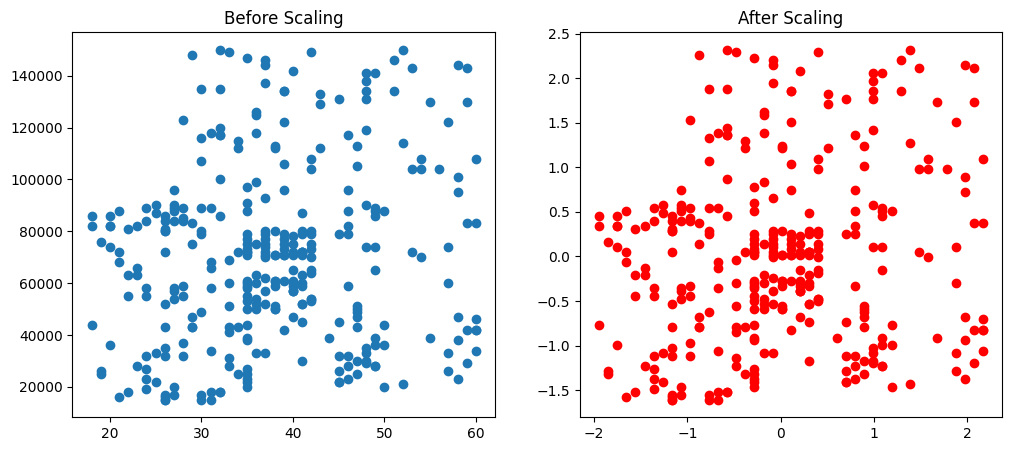

In [70]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

# Comparison of Distributions

### Scaling only the scale changes, not the distribution. 

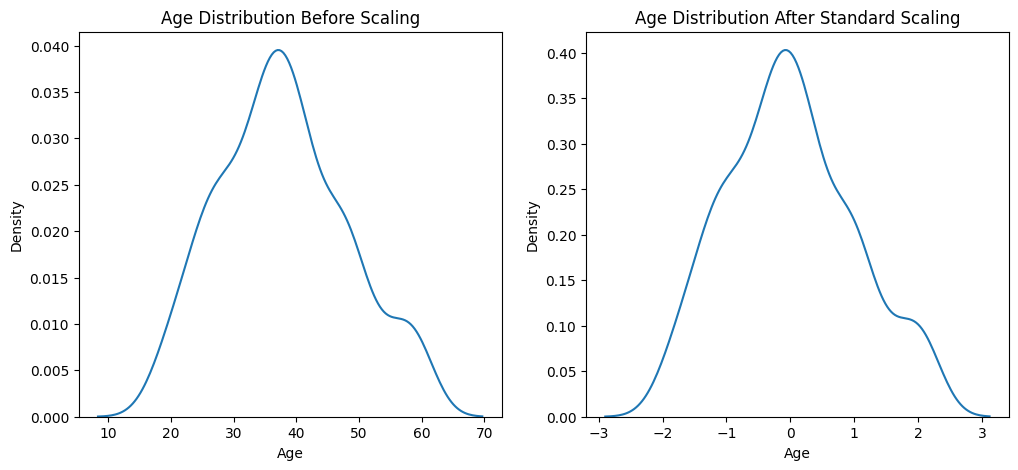

In [71]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
plt.show()